<a href="https://colab.research.google.com/github/dashy0070/Cybersecurity_AI/blob/main/IOT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from scapy.all import rdpcap

file_path = '/content/2019-07-03-15-15-47-first_start_somfy_gateway.pcap'

try:
    # Read the pcap file
    packets = rdpcap(file_path)
    print(f"Successfully loaded {len(packets)} packets from {file_path}")

    # Display a summary of the first few packets
    if packets:
        print("\nSummary of first 5 packets:")
        for i, packet in enumerate(packets[:20]):
            print(f"Packet {i+1}: {packet.summary()}")
    else:
        print("The .pcap file contains no packets.")

except Exception as e:
    print(f"Error reading .pcap file with scapy: {e}")
    print("This could be due to file corruption, an unsupported .pcap format, or other issues.")

Successfully loaded 8276 packets from /content/2019-07-03-15-15-47-first_start_somfy_gateway.pcap

Summary of first 5 packets:
Packet 1: 00:1c:57:75:4f:98 > 00:1c:57:75:4f:98 (0x9000) / Raw
Packet 2: 802.3 00:1c:57:75:4f:98 > 01:00:0c:cc:cc:cc / LLC / SNAP / Raw
Packet 3: 00:1c:57:75:4f:98 > 00:1c:57:75:4f:98 (0x9000) / Raw
Packet 4: 00:1c:57:75:4f:98 > 00:1c:57:75:4f:98 (0x9000) / Raw
Packet 5: 00:1c:57:75:4f:98 > 00:1c:57:75:4f:98 (0x9000) / Raw
Packet 6: 00:1c:57:75:4f:98 > 00:1c:57:75:4f:98 (0x9000) / Raw
Packet 7: 00:1c:57:75:4f:98 > 00:1c:57:75:4f:98 (0x9000) / Raw
Packet 8: 00:1c:57:75:4f:98 > 00:1c:57:75:4f:98 (0x9000) / Raw
Packet 9: Ether / IP / UDP / BOOTP / DHCP Discover
Packet 10: Ether / IP / UDP / BOOTP / DHCP Discover
Packet 11: Ether / IP / UDP / BOOTP / DHCP Discover
Packet 12: 802.3 00:1c:57:75:4f:98 > 01:00:0c:cc:cc:cc / LLC / SNAP / Raw
Packet 13: 00:1c:57:75:4f:98 > 00:1c:57:75:4f:98 (0x9000) / Raw
Packet 14: Ether / IP / UDP / BOOTP / DHCP Discover
Packet 15: Eth

### Data Preprocessing

Prompt: Perform preprocessing on the IoT-23 dataset:
1. Drop irrelevant columns such as timestamps or IDs.
2. Convert the label column into binary values (0 for benign, 1 for malicious).
3. Encode categorical features using LabelEncoder or OneHotEncoding.
4. Handle missing values.
5. Separate the dataset into X (features) and y (target).

In [ ]:
import pandas as pd
from scapy.all import Ether, IP, TCP, UDP
from sklearn.preprocessing import LabelEncoder

# Assuming 'packets' is already loaded from the previous step
# If not, uncomment and run the following line:
# from scapy.all import rdpcap
# file_path = '/content/2019-07-03-15-15-47-first_start_somfy_gateway.pcap'
# packets = rdpcap(file_path)

# --- Step 1: Convert Scapy PacketList to Pandas DataFrame ---
# This is a crucial step to apply DataFrame-based preprocessing.
# We'll extract common network features. For a full IoT-23 dataset, more specific features
# might be defined, but this covers general packet analysis.

data = []
for i, packet in enumerate(packets):
    # Initialize with common fields
    row = {
        'packet_num': i + 1,
        'timestamp': packet.time if hasattr(packet, 'time') else None,
        'src_mac': packet.src if Ether in packet else None,
        'dst_mac': packet.dst if Ether in packet else None,
        'protocol': 'Unknown_Protocol', # Initialize as string
        'src_ip': None,
        'dst_ip': None,
        'src_port': None,
        'dst_port': None,
        'payload_len': len(packet) # Total packet length
    }

    # Extract IP layer information if present
    if IP in packet:
        # Ensure protocol number is converted to string
        row['protocol'] = str(packet[IP].proto)
        row['src_ip'] = packet[IP].src
        row['dst_ip'] = packet[IP].dst

    # Extract TCP/UDP port information if present (will overwrite IP protocol if present)
    if TCP in packet:
        row['src_port'] = packet[TCP].sport
        row['dst_port'] = packet[TCP].dport
        row['protocol'] = 'TCP'
    elif UDP in packet:
        row['src_port'] = packet[UDP].sport
        row['dst_port'] = packet[UDP].dport
        row['protocol'] = 'UDP'

    # Add a dummy 'label' for demonstration purposes (as .pcap doesn't have inherent labels)
    # In a real scenario, this would come from a known dataset or external analysis.
    # Let's create a mix of 'Benign' and 'Malicious' labels based on some arbitrary condition
    if row['dst_port'] == 80 or row['dst_port'] == 443 or (row['src_ip'] and '192.168' in str(row['src_ip']) and '192.168' in str(row['dst_ip'])):
        row['label'] = 'Benign'
    elif row['protocol'] == 'TCP' and row['dst_port'] in [23, 22]: # Example of suspicious ports
        row['label'] = 'Malicious'
    else:
        row['label'] = 'Unknown'

    data.append(row)

df = pd.DataFrame(data)

print("Original DataFrame head after extraction:")
print(df.head())
print(f"\nOriginal DataFrame shape: {df.shape}")

# --- Preprocessing Steps ---

# 1. Drop irrelevant columns such as timestamps or IDs.
# 'packet_num' is an ID, and 'timestamp' might be considered irrelevant for some models
# For MAC addresses, we'll keep them for now as they can be useful features but could be dropped.
columns_to_drop = ['timestamp', 'packet_num']
df_processed = df.drop(columns=columns_to_drop, errors='ignore')
print(f"\nShape after dropping columns {columns_to_drop}: {df_processed.shape}")

# 2. Convert the label column into binary values (0 for benign, 1 for malicious).
# Assuming 'Benign' is 0, 'Malicious' is 1. 'Unknown' will be handled or re-classified.
label_mapping = {'Benign': 0, 'Malicious': 1, 'Unknown': -1} # Use -1 for unknown for now
df_processed['label_binary'] = df_processed['label'].map(label_mapping)
# Drop original 'label' column if not needed further
df_processed = df_processed.drop(columns=['label'])
print("\nLabel column converted to binary (0=Benign, 1=Malicious, -1=Unknown):")
print(df_processed[['label_binary']].value_counts())

# 3. Encode categorical features using LabelEncoder or OneHotEncoding.
# Identifying categorical columns. We'll use LabelEncoder for simplicity and to avoid too many columns.
categorical_cols = ['src_mac', 'dst_mac', 'protocol', 'src_ip', 'dst_ip'] # Added src_ip, dst_ip as they might be categorical strings

for col in categorical_cols:
    if col in df_processed.columns:
        # Fill potential NaNs before encoding to treat them as a separate category
        df_processed[col] = df_processed[col].fillna('Unknown_Category')
        le = LabelEncoder()
        df_processed[f'{col}_encoded'] = le.fit_transform(df_processed[col].astype(str)) # Ensure all values are strings before encoding
        # Optionally, drop the original categorical column
        df_processed = df_processed.drop(columns=[col])
print("\nCategorical features encoded:")
print(df_processed.head())

# 4. Handle missing values.
# We already filled NaNs in categorical columns during encoding.
# For numerical columns, let's fill with the mean or median, or drop rows.
# For demonstration, we'll fill numerical NaNs with 0 (or median).
# Identify numerical columns for NaN handling
numerical_cols = df_processed.select_dtypes(include=['number']).columns
for col in numerical_cols:
    # Check if there are actual NaNs before filling
    if df_processed[col].isnull().any():
        df_processed[col] = df_processed[col].fillna(df_processed[col].median())

print(f"\nMissing values after handling:\n{df_processed.isnull().sum()[df_processed.isnull().sum() > 0]}")

# 5. Separate the dataset into X (features) and y (target).
# The target variable is 'label_binary'
X = df_processed.drop(columns=['label_binary'])
y = df_processed['label_binary']

print(f"\nShape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")
print("\nFirst 5 rows of X:")
print(X.head())
print("\nFirst 5 rows of y:")
print(y.head())

Original DataFrame head after extraction:
   packet_num          timestamp            src_mac            dst_mac  \
0           1  1562159754.654715  00:1c:57:75:4f:98  00:1c:57:75:4f:98   
1           2  1562159763.741786               None               None   
2           3  1562159764.662261  00:1c:57:75:4f:98  00:1c:57:75:4f:98   
3           4  1562159774.661815  00:1c:57:75:4f:98  00:1c:57:75:4f:98   
4           5  1562159784.669110  00:1c:57:75:4f:98  00:1c:57:75:4f:98   

           protocol src_ip dst_ip  src_port  dst_port  payload_len    label  
0  Unknown_Protocol   None   None       NaN       NaN           60  Unknown  
1  Unknown_Protocol   None   None       NaN       NaN          369  Unknown  
2  Unknown_Protocol   None   None       NaN       NaN           60  Unknown  
3  Unknown_Protocol   None   None       NaN       NaN           60  Unknown  
4  Unknown_Protocol   None   None       NaN       NaN           60  Unknown  

Original DataFrame shape: (8276, 11)

Shape 

### Feature Correlation Visualization

Prompt: Generate a feature correlation matrix for the dataset and visualize it using a heatmap with seaborn.
- Highlight the relationships between features and the target variable.
- Use appropriate figure size and annotations for readability.

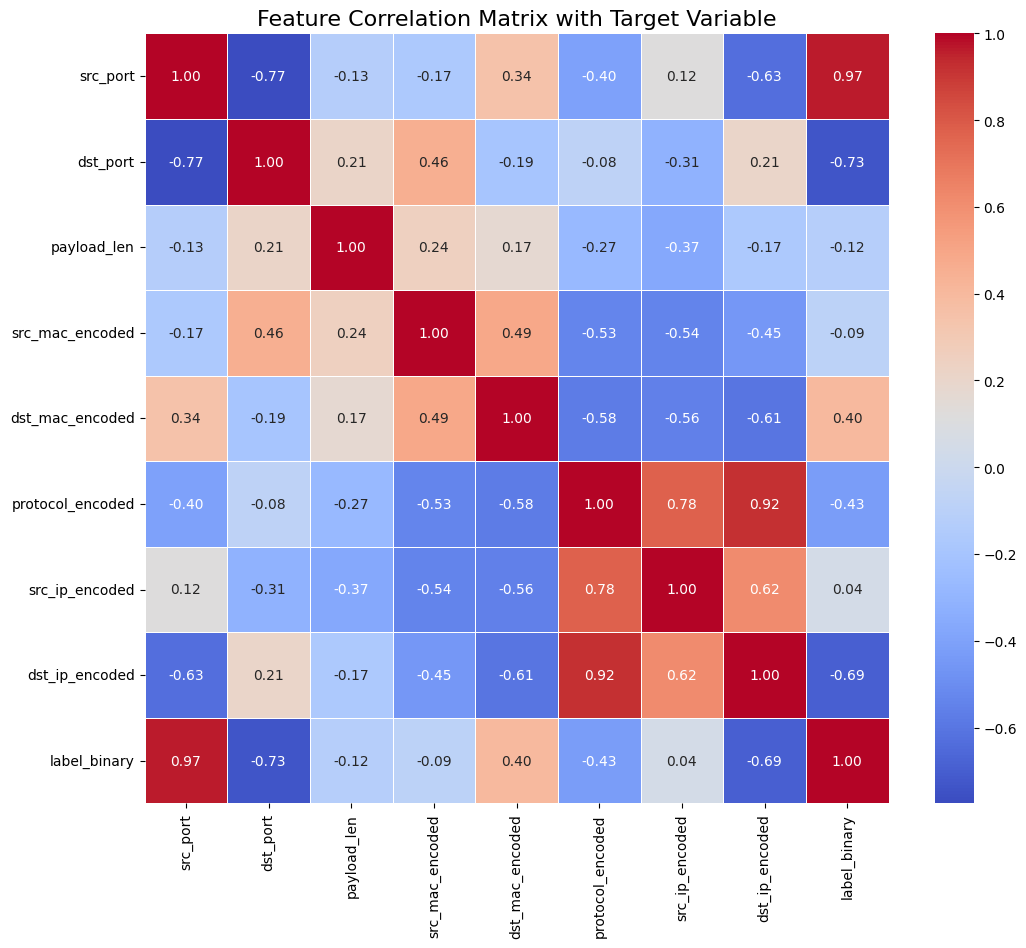

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure X and y are DataFrames/Series (from previous preprocessing step)
# Combine features (X) and target (y) into a single DataFrame for correlation calculation
df_combined = pd.concat([X, y], axis=1)

# Calculate the correlation matrix
correlation_matrix = df_combined.corr()

# Set up the matplotlib figure and a seaborn heatmap
plt.figure(figsize=(12, 10)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Matrix with Target Variable', fontsize=16)
plt.show()

### Feature Scaling

Prompt: Normalize all numerical features in X using StandardScaler.
Ensure the target variable y is not scaled.
Display the first five rows of the scaled feature set.

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the features in X
X_scaled = scaler.fit_transform(X)

# Convert the scaled array back to a DataFrame for easier inspection
# Use the original column names from X
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("First 5 rows of the scaled feature set (X_scaled_df):")
print(X_scaled_df.head())

First 5 rows of the scaled feature set (X_scaled_df):
   src_port  dst_port  payload_len  src_mac_encoded  dst_mac_encoded  \
0 -0.744139 -0.038885    -0.639873        -1.610738        -2.941689   
1 -0.744139 -0.038885     0.477000         1.356204         1.008067   
2 -0.744139 -0.038885    -0.639873        -1.610738        -2.941689   
3 -0.744139 -0.038885    -0.639873        -1.610738        -2.941689   
4 -0.744139 -0.038885    -0.639873        -1.610738        -2.941689   

   protocol_encoded  src_ip_encoded  dst_ip_encoded  
0          1.824665        1.507247         1.56881  
1          1.824665        1.507247         1.56881  
2          1.824665        1.507247         1.56881  
3          1.824665        1.507247         1.56881  
4          1.824665        1.507247         1.56881  


### Train-Test Split

Prompt: Split the dataset into training and testing sets using an 80/20 ratio.
Use stratified splitting based on the target variable to maintain class distribution.
Set random_state=42 for reproducibility.
Display the shape of X_train, X_test, y_train, and y_test.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (80/20 ratio)
# Use X_scaled_df as the features since it's the scaled version
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)

# Display the shapes of the resulting sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (6620, 8)
Shape of X_test: (1656, 8)
Shape of y_train: (6620,)
Shape of y_test: (1656,)


### Build Binary Classification Model

Prompt: Build a binary classification model to distinguish between benign and malicious IoT traffic using RandomForestClassifier.
Train the model on the training dataset and display the training accuracy.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize the RandomForestClassifier model
# Using random_state for reproducibility
model = RandomForestClassifier(random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

# Predict on the training set
y_train_pred = model.predict(X_train)

# Calculate training accuracy
training_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training Accuracy of RandomForestClassifier: {training_accuracy:.4f}")

Training Accuracy of RandomForestClassifier: 1.0000


### Model Prediction

Prompt: Use the trained model to make predictions on the test dataset.
Generate predicted labels and predicted probabilities for evaluation.

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Get predicted probabilities for the test set
# .predict_proba() returns probabilities for each class (e.g., [prob_class_0, prob_class_1])
y_pred_proba = model.predict_proba(X_test)

print("First 5 predicted labels:")
print(y_pred[:5])

print("\nFirst 5 predicted probabilities (for each class):")
print(y_pred_proba[:5])

First 5 predicted labels:
[-1 -1  0 -1 -1]

First 5 predicted probabilities (for each class):
[[1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]]


### Model Evaluation

Prompt: Evaluate the binary classification model using the test dataset.
Generate the following metrics:

1. F1-score
2. Confusion matrix
3. ROC curve
4. Area Under the ROC Curve (AUC)

Display the ROC curve plot and print the AUC score.

Accuracy Score: 1.0000
F1-Score (weighted): 1.0000

Classification Report:
              precision    recall  f1-score   support

     Unknown       1.00      1.00      1.00      1107
      Benign       1.00      1.00      1.00       549

    accuracy                           1.00      1656
   macro avg       1.00      1.00      1.00      1656
weighted avg       1.00      1.00      1.00      1656



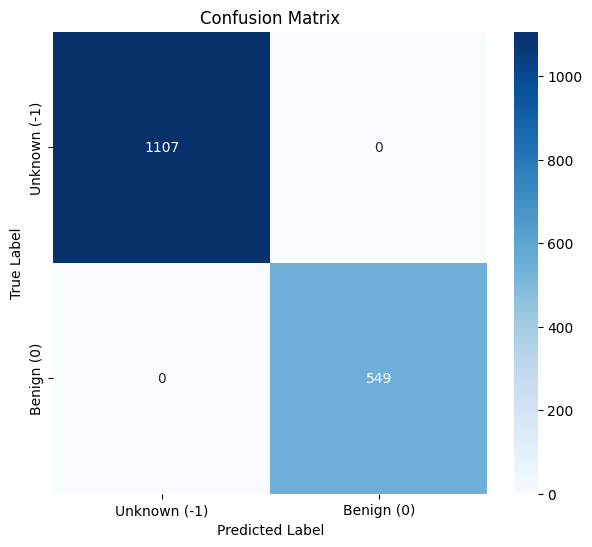


Area Under the Receiver Operating Characteristic Curve (AUC): 1.0000


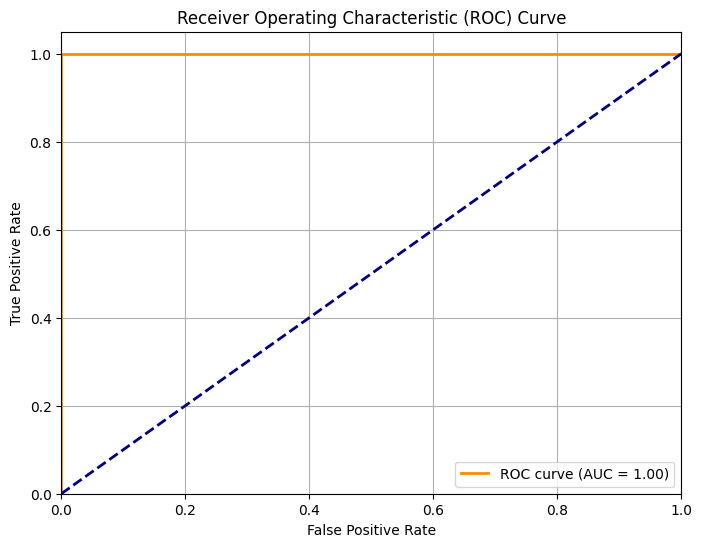

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, roc_auc_score, RocCurveDisplay, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Accuracy Score ---
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

# --- 2. F1-score ---
# Calculate F1-score. Using 'weighted' average to account for class imbalance
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score (weighted): {f1:.4f}")

# --- 3. Classification Report ---
# Define target names to make the report more readable
target_names = { -1: 'Unknown', 0: 'Benign' }
# Sort the unique labels from y_test and create a list of target names in that order
sorted_labels = sorted(y_test.unique())
sorted_target_names = [target_names[label] for label in sorted_labels]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=sorted_labels, target_names=sorted_target_names))

# --- 4. Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
# Define labels based on the unique values in y_test or model.classes_
labels = ['Unknown (-1)', 'Benign (0)']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# --- 5. and 6. ROC curve and Area Under the ROC Curve (AUC) ---
# The model.predict_proba() output for a RandomForestClassifier typically provides probabilities
# for classes in the order they appear in model.classes_.
# Based on previous output, y_pred_proba[:, 0] is for class -1 and y_pred_proba[:, 1] for class 0.
# We will use class 0 (Benign) as the positive class for ROC/AUC.

y_score = y_pred_proba[:, 1] # Probabilities for the positive class (class 0: Benign)

# Calculate AUC
# Ensure labels are explicitly passed to roc_auc_score if y_test contains non-standard labels like -1
auc_score = roc_auc_score(y_test, y_score, labels=sorted_labels) # Correctly specify all possible labels if necessary
print(f"\nArea Under the Receiver Operating Characteristic Curve (AUC): {auc_score:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=0) # pos_label=0 specifies 'Benign' as the positive class
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Visualization

Prompt: Visualize the feature importance from the trained Random Forest model using a bar chart to identify the most influential network traffic features.

/tmp/ipykernel_1129/2318490925.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


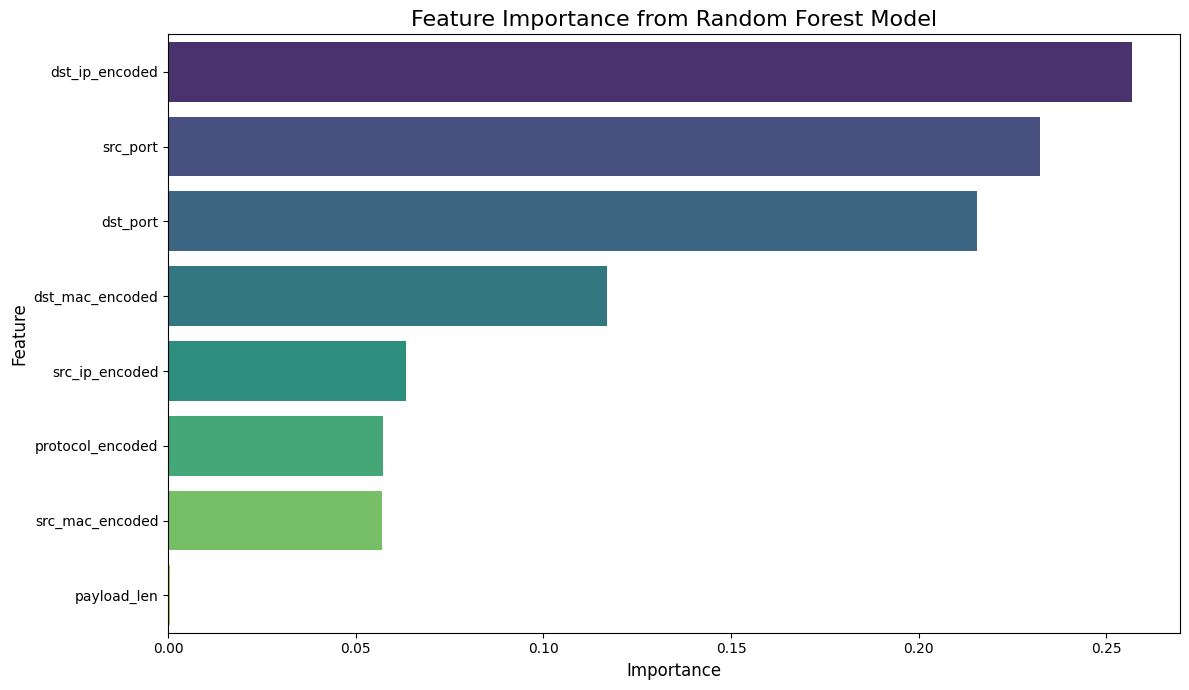

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Get feature names from X_train
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance from Random Forest Model', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()